# PubMedQA L1 and L2 Schema Analysis - Answer Distribution Including Invalid JSON

This notebook analyzes the L1 and L2 schema-constrained results for PubMedQA, including answer distribution with invalid JSON cases, schema compliance metrics, and L2-specific confidence score analysis.


In [33]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Set style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


## Load L1 Results and Samples


In [34]:
# Load L1 result JSON
l1_result_file = "pubmedqa_level1_2025-12-08T14-28-16.793274.json"

with open(l1_result_file, 'r') as f:
    l1_results = json.load(f)

l1_exact_match = l1_results['results']['pubmedqa_generation']['exact_match,strict-match']
l1_exact_match_stderr = l1_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("L1 PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {l1_exact_match:.4f} ± {l1_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {l1_exact_match*100:.2f}%")
print("="*60)


L1 PERFORMANCE METRICS
Exact Match Score: 0.7720 ± 0.0188
Exact Match Percentage: 77.20%


## Load L2 Results


In [35]:
# Load L2 result JSON
l2_result_file = "pubmedqa_level2_2025-12-08T14-33-38.031833.json"

with open(l2_result_file, 'r') as f:
    l2_results = json.load(f)

l2_exact_match = l2_results['results']['pubmedqa_generation']['exact_match,strict-match']
l2_exact_match_stderr = l2_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("L2 PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {l2_exact_match:.4f} ± {l2_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {l2_exact_match*100:.2f}%")
print("="*60)

# Comparison with Baseline and L1
print("\n" + "="*60)
print("BASELINE vs L1 vs L2 COMPARISON")
print("="*60)
print(f"Baseline: {baseline_exact_match*100:.2f}% ± {baseline_exact_match_stderr*100:.2f}%")
print(f"L1:       {l1_exact_match*100:.2f}% ± {l1_exact_match_stderr*100:.2f}%")
print(f"L2:       {l2_exact_match*100:.2f}% ± {l2_exact_match_stderr*100:.2f}%")
diff_l1 = (l1_exact_match - baseline_exact_match) * 100
diff_l2 = (l2_exact_match - baseline_exact_match) * 100
diff_l2_l1 = (l2_exact_match - l1_exact_match) * 100
print(f"\nL1 vs Baseline: {diff_l1:+.2f} percentage points")
print(f"L2 vs Baseline: {diff_l2:+.2f} percentage points")
print(f"L2 vs L1: {diff_l2_l1:+.2f} percentage points")
print("="*60)


L2 PERFORMANCE METRICS
Exact Match Score: 0.7740 ± 0.0187
Exact Match Percentage: 77.40%

BASELINE vs L1 vs L2 COMPARISON
Baseline: 76.20% ± 1.91%
L1:       77.20% ± 1.88%
L2:       77.40% ± 1.87%

L1 vs Baseline: +1.00 percentage points
L2 vs Baseline: +1.20 percentage points
L2 vs L1: +0.20 percentage points


## Load Baseline Results


In [ ]:
# Load baseline result JSON from pubmedqa_new directory
baseline_result_file = "../pubmedqa_new/pubmedqa_baseline_2025-12-02T17-10-15.514633.json"

with open(baseline_result_file, 'r') as f:
    baseline_results = json.load(f)

baseline_exact_match = baseline_results['results']['pubmedqa_generation']['exact_match,strict-match']
baseline_exact_match_stderr = baseline_results['results']['pubmedqa_generation']['exact_match_stderr,strict-match']

print("="*60)
print("BASELINE PERFORMANCE METRICS")
print("="*60)
print(f"Exact Match Score: {baseline_exact_match:.4f} ± {baseline_exact_match_stderr:.4f}")
print(f"Exact Match Percentage: {baseline_exact_match*100:.2f}%")
print("="*60)

# Comparison
print("\n" + "="*60)
print("L1 vs BASELINE COMPARISON")
print("="*60)
print(f"Baseline: {baseline_exact_match*100:.2f}% ± {baseline_exact_match_stderr*100:.2f}%")
print(f"L1:       {l1_exact_match*100:.2f}% ± {l1_exact_match_stderr*100:.2f}%")
diff = (l1_exact_match - baseline_exact_match) * 100
print(f"Difference: {diff:+.2f} percentage points")
print("="*60)


BASELINE PERFORMANCE METRICS
Exact Match Score: 0.7620 ± 0.0191
Exact Match Percentage: 76.20%

L1 vs BASELINE COMPARISON
Baseline: 76.20% ± 1.91%
L1:       77.20% ± 1.88%
Difference: +1.00 percentage points


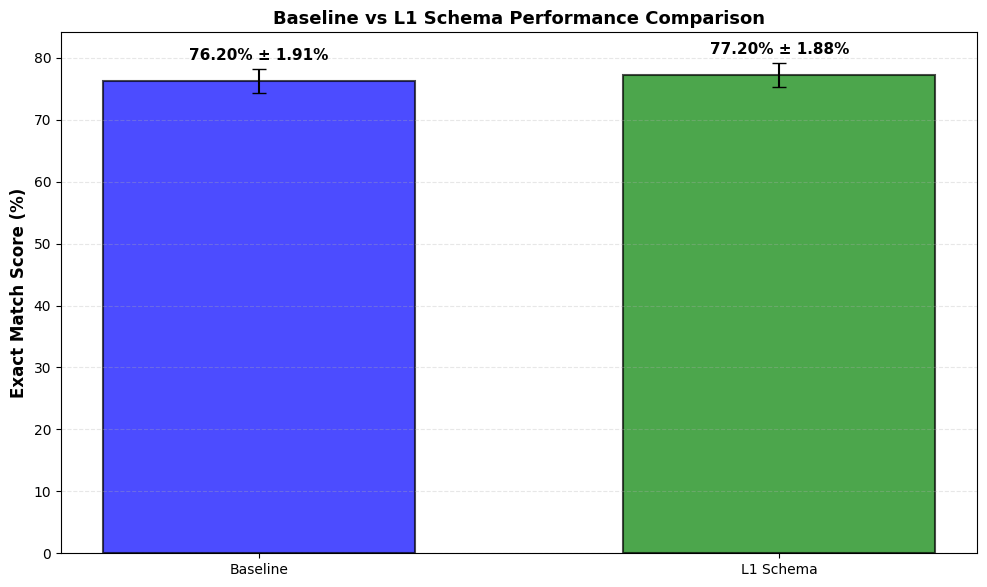

In [ ]:
# Visualize Baseline vs L1 comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models = ['Baseline', 'L1 Schema']
scores = [baseline_exact_match * 100, l1_exact_match * 100]
errors = [baseline_exact_match_stderr * 100, l1_exact_match_stderr * 100]

x_pos = np.arange(len(models))
bars = ax.bar(x_pos, scores, yerr=errors, capsize=5, 
              color=['blue', 'green'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)

for i, (bar, score, error) in enumerate(zip(bars, scores, errors)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + error + 1,
            f'{score:.2f}% ± {error:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Exact Match Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Baseline vs L1 Schema Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim([0, max(scores) + max(errors) + 5])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## Baseline Answer Distribution Analysis


In [38]:
# Load baseline samples and extract answer distribution
baseline_samples_file = "../pubmedqa_new/samples_pubmedqa_generation_baseline.jsonl"

baseline_answers = []
baseline_responses = []
baseline_filtered_responses = []

with open(baseline_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Extract answer from filtered_resp (baseline uses regex extraction)
        answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        baseline_answers.append(answer)
        baseline_responses.append(raw_resp if raw_resp else '')
        baseline_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
baseline_answer_counts = Counter(baseline_answers)
baseline_categories = ['yes', 'no', 'maybe', '[invalid]']
baseline_counts = [baseline_answer_counts.get(cat, 0) for cat in baseline_categories]

baseline_total = len(baseline_answers)

print("="*60)
print("BASELINE ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution:")
for cat, count in zip(baseline_categories, baseline_counts):
    percentage = count / baseline_total * 100 if baseline_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {baseline_total}")
print(f"Valid answers (yes+no+maybe): {sum(baseline_counts[:3])} ({sum(baseline_counts[:3])/baseline_total*100:.2f}%)")
print(f"Invalid answers: {baseline_counts[3]} ({baseline_counts[3]/baseline_total*100:.2f}%)")
print("="*60)


BASELINE ANSWER DISTRIBUTION

Answer Distribution:
  yes         :  344 (68.80%)
  no          :  151 (30.20%)
  maybe       :    2 ( 0.40%)
  [invalid]   :    3 ( 0.60%)

Total samples: 500
Valid answers (yes+no+maybe): 497 (99.40%)
Invalid answers: 3 (0.60%)


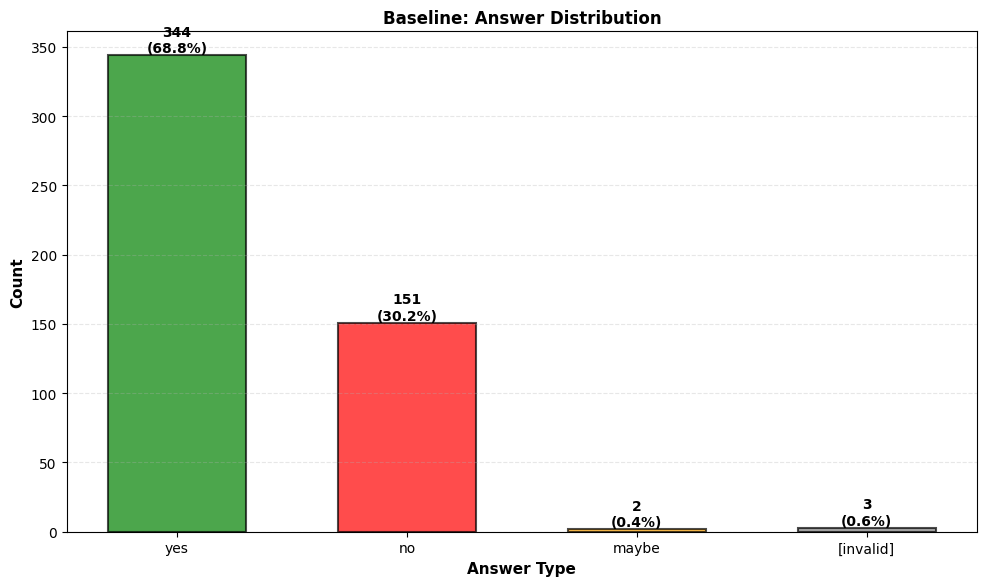

In [40]:
# Visualize Baseline Answer Distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

x_pos = np.arange(len(baseline_categories))
bars = ax.bar(x_pos, baseline_counts, color=['green', 'red', 'orange', 'gray'], 
              alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)

for bar, count in zip(bars, baseline_counts):
    height = bar.get_height()
    percentage = count / baseline_total * 100 if baseline_total > 0 else 0
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Baseline: Answer Distribution', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(baseline_categories, fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## Answer Distribution Analysis (Including Invalid JSON)


In [42]:
# Load L1 samples and extract data
l1_samples_file = "samples_pubmedqa_generation_L1.jsonl"

l1_answers = []
l1_valid_json = []
l1_has_answer = []
l1_answer_valid = []
l1_responses = []
l1_filtered_responses = []

# Helper function to extract JSON by finding matching braces
def extract_json_from_text(text):
    """Extract JSON from text, handling incomplete JSON."""
    if not text or not isinstance(text, str):
        return None
    
    text_cleaned = text.strip()
    
    # Try direct parse first (most common case)
    try:
        return json.loads(text_cleaned)
    except (json.JSONDecodeError, TypeError):
        pass
    
    # Try to find complete JSON object using balanced braces
    start_idx = text_cleaned.find('{')
    if start_idx == -1:
        return None
    
    # Count braces to find the matching closing brace
    brace_count = 0
    for i in range(start_idx, len(text_cleaned)):
        if text_cleaned[i] == '{':
            brace_count += 1
        elif text_cleaned[i] == '}':
            brace_count -= 1
            if brace_count == 0:
                # Found matching closing brace
                json_str = text_cleaned[start_idx:i+1]
                try:
                    return json.loads(json_str)
                except (json.JSONDecodeError, TypeError):
                    return None
    return None

with open(l1_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Try to parse JSON from raw response
        json_valid = False
        answer = None
        has_answer_field = False
        answer_is_valid_enum = False
        
        if raw_resp and isinstance(raw_resp, str):
            # Extract and parse JSON
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                json_valid = True
                answer = parsed.get('answer', '').lower().strip() if parsed.get('answer') else None
                has_answer_field = answer is not None
                answer_is_valid_enum = answer in ['yes', 'no', 'maybe']
        
        # If JSON parsing failed, fallback to filtered_resp for answer
        if not json_valid:
            answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        l1_answers.append(answer)
        l1_valid_json.append(json_valid)
        l1_has_answer.append(has_answer_field)
        l1_answer_valid.append(answer_is_valid_enum)
        l1_responses.append(raw_resp if raw_resp else '')
        l1_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
l1_answer_counts = Counter(l1_answers)
l1_categories = ['yes', 'no', 'maybe', '[invalid]']
l1_counts = [l1_answer_counts.get(cat, 0) for cat in l1_categories]

# Calculate schema compliance
l1_total = len(l1_answers)
l1_valid_json_count = sum(l1_valid_json)
l1_compliant = sum([l1_valid_json[i] and l1_has_answer[i] and l1_answer_valid[i] 
                    for i in range(l1_total)])

print("="*60)
print("L1 SCHEMA ANALYSIS - ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution (including invalid JSON):")
for cat, count in zip(l1_categories, l1_counts):
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {l1_total}")
print(f"Valid answers (yes+no+maybe): {sum(l1_counts[:3])} ({sum(l1_counts[:3])/l1_total*100:.2f}%)")
print(f"Invalid answers: {l1_counts[3]} ({l1_counts[3]/l1_total*100:.2f}%)")

print(f"\nJSON Validity:")
print(f"  Valid JSON: {l1_valid_json_count}/{l1_total} ({l1_valid_json_count/l1_total*100:.2f}%)")
print(f"  Invalid JSON: {l1_total - l1_valid_json_count}/{l1_total} ({(l1_total - l1_valid_json_count)/l1_total*100:.2f}%)")

print(f"\nAnswer Distribution Breakdown:")
print(f"  Valid JSON with valid answer: {l1_compliant} ({l1_compliant/l1_total*100:.2f}%)")
print(f"  Invalid JSON (fallback to filtered_resp): {l1_total - l1_valid_json_count} ({(l1_total - l1_valid_json_count)/l1_total*100:.2f}%)")
print(f"  Invalid JSON → [invalid] answer: {l1_counts[3]} ({l1_counts[3]/l1_total*100:.2f}%)")
print("="*60)


L1 SCHEMA ANALYSIS - ANSWER DISTRIBUTION

Answer Distribution (including invalid JSON):
  yes         :  315 (63.00%)
  no          :  185 (37.00%)
  maybe       :    0 ( 0.00%)
  [invalid]   :    0 ( 0.00%)

Total samples: 500
Valid answers (yes+no+maybe): 500 (100.00%)
Invalid answers: 0 (0.00%)

JSON Validity:
  Valid JSON: 500/500 (100.00%)
  Invalid JSON: 0/500 (0.00%)

Answer Distribution Breakdown:
  Valid JSON with valid answer: 500 (100.00%)
  Invalid JSON (fallback to filtered_resp): 0 (0.00%)
  Invalid JSON → [invalid] answer: 0 (0.00%)


## L2 Answer Distribution Analysis (Including Invalid JSON)


In [43]:
# Load L2 samples and extract data
l2_samples_file = "samples_pubmedqa_generation_L2.jsonl"

l2_answers = []
l2_confidences = []
l2_valid_json = []
l2_has_answer = []
l2_has_confidence = []
l2_answer_valid = []
l2_confidence_valid = []
l2_both_fields = []
l2_responses = []
l2_filtered_responses = []

# Reuse the extract_json_from_text function from L1 analysis
# (It's already defined in cell 12, but we'll use it here)

with open(l2_samples_file, 'r') as f:
    for line in f:
        sample = json.loads(line)
        
        # Get raw response (first element of first list)
        raw_resp = sample.get('resps', [[None]])[0][0] if sample.get('resps') else None
        filtered_resp = sample.get('filtered_resps', ['[invalid]'])[0]
        
        # Try to parse JSON from raw response
        json_valid = False
        answer = None
        confidence = None
        has_answer_field = False
        has_confidence_field = False
        answer_is_valid_enum = False
        confidence_is_valid = False
        
        if raw_resp and isinstance(raw_resp, str):
            # Extract and parse JSON
            parsed = extract_json_from_text(raw_resp)
            if parsed and isinstance(parsed, dict):
                json_valid = True
                answer = parsed.get('answer', '').lower().strip() if parsed.get('answer') else None
                has_answer_field = answer is not None
                answer_is_valid_enum = answer in ['yes', 'no', 'maybe']
                
                # Extract confidence
                confidence_val = parsed.get('confidence')
                if confidence_val is not None:
                    try:
                        confidence = float(confidence_val)
                        has_confidence_field = True
                        confidence_is_valid = (0.0 <= confidence <= 1.0)
                    except (ValueError, TypeError):
                        confidence = None
                        has_confidence_field = False
                        confidence_is_valid = False
        
        # If JSON parsing failed, fallback to filtered_resp for answer
        if not json_valid:
            answer = filtered_resp.lower().strip() if filtered_resp else '[invalid]'
        
        # Normalize answer
        if answer not in ['yes', 'no', 'maybe']:
            answer = '[invalid]'
        
        l2_answers.append(answer)
        l2_confidences.append(confidence)
        l2_valid_json.append(json_valid)
        l2_has_answer.append(has_answer_field)
        l2_has_confidence.append(has_confidence_field)
        l2_answer_valid.append(answer_is_valid_enum)
        l2_confidence_valid.append(confidence_is_valid)
        l2_both_fields.append(has_answer_field and has_confidence_field)
        l2_responses.append(raw_resp if raw_resp else '')
        l2_filtered_responses.append(filtered_resp if filtered_resp else '[invalid]')

# Count occurrences
l2_answer_counts = Counter(l2_answers)
l2_categories = ['yes', 'no', 'maybe', '[invalid]']
l2_counts = [l2_answer_counts.get(cat, 0) for cat in l2_categories]

# Calculate schema compliance
l2_total = len(l2_answers)
l2_valid_json_count = sum(l2_valid_json)
l2_compliant = sum([l2_valid_json[i] and l2_has_answer[i] and l2_has_confidence[i] 
                     and l2_answer_valid[i] and l2_confidence_valid[i] 
                     for i in range(l2_total)])

print("="*60)
print("L2 SCHEMA ANALYSIS - ANSWER DISTRIBUTION")
print("="*60)
print(f"\nAnswer Distribution (including invalid JSON):")
for cat, count in zip(l2_categories, l2_counts):
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    print(f"  {cat:12s}: {count:4d} ({percentage:5.2f}%)")
print(f"\nTotal samples: {l2_total}")
print(f"Valid answers (yes+no+maybe): {sum(l2_counts[:3])} ({sum(l2_counts[:3])/l2_total*100:.2f}%)")
print(f"Invalid answers: {l2_counts[3]} ({l2_counts[3]/l2_total*100:.2f}%)")

print(f"\nJSON Validity:")
print(f"  Valid JSON: {l2_valid_json_count}/{l2_total} ({l2_valid_json_count/l2_total*100:.2f}%)")
print(f"  Invalid JSON: {l2_total - l2_valid_json_count}/{l2_total} ({(l2_total - l2_valid_json_count)/l2_total*100:.2f}%)")

print(f"\nSchema Compliance:")
print(f"  Has answer field: {sum(l2_has_answer)}/{l2_total} ({sum(l2_has_answer)/l2_total*100:.2f}%)")
print(f"  Has confidence field: {sum(l2_has_confidence)}/{l2_total} ({sum(l2_has_confidence)/l2_total*100:.2f}%)")
print(f"  Both fields present: {sum(l2_both_fields)}/{l2_total} ({sum(l2_both_fields)/l2_total*100:.2f}%)")
print(f"  Answer is valid enum: {sum(l2_answer_valid)}/{l2_total} ({sum(l2_answer_valid)/l2_total*100:.2f}%)")
print(f"  Confidence in range [0.0, 1.0]: {sum(l2_confidence_valid)}/{l2_total} ({sum(l2_confidence_valid)/l2_total*100:.2f}%)")
print(f"  Full schema compliance: {l2_compliant}/{l2_total} ({l2_compliant/l2_total*100:.2f}%)")
print("="*60)


L2 SCHEMA ANALYSIS - ANSWER DISTRIBUTION

Answer Distribution (including invalid JSON):
  yes         :  312 (62.40%)
  no          :  188 (37.60%)
  maybe       :    0 ( 0.00%)
  [invalid]   :    0 ( 0.00%)

Total samples: 500
Valid answers (yes+no+maybe): 500 (100.00%)
Invalid answers: 0 (0.00%)

JSON Validity:
  Valid JSON: 500/500 (100.00%)
  Invalid JSON: 0/500 (0.00%)

Schema Compliance:
  Has answer field: 500/500 (100.00%)
  Has confidence field: 500/500 (100.00%)
  Both fields present: 500/500 (100.00%)
  Answer is valid enum: 500/500 (100.00%)
  Confidence in range [0.0, 1.0]: 500/500 (100.00%)
  Full schema compliance: 500/500 (100.00%)


## L2 Confidence Score Statistics


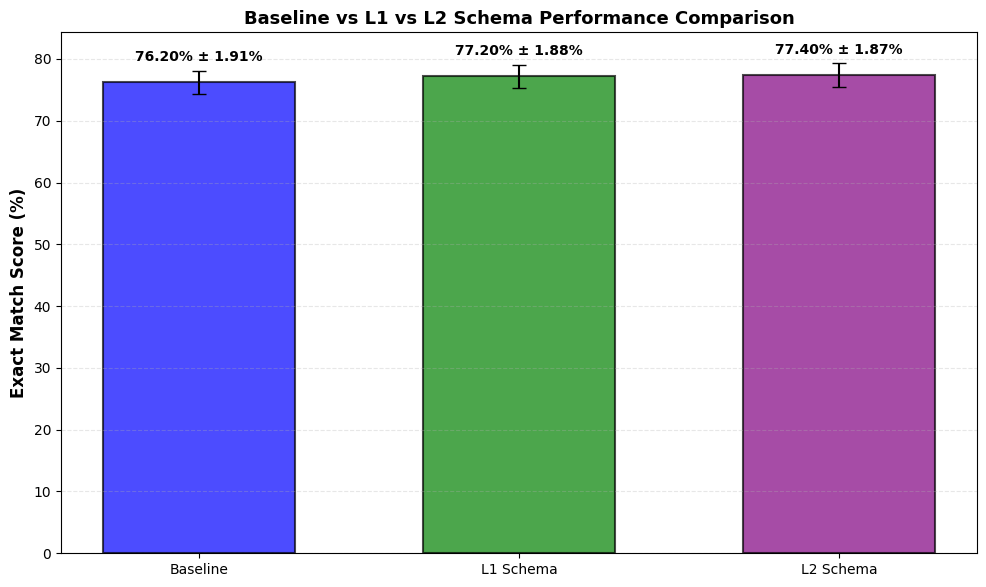

In [44]:
# Performance Metrics Comparison Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models = ['Baseline', 'L1 Schema', 'L2 Schema']
scores = [baseline_exact_match * 100, l1_exact_match * 100, l2_exact_match * 100]
errors = [baseline_exact_match_stderr * 100, l1_exact_match_stderr * 100, l2_exact_match_stderr * 100]

x_pos = np.arange(len(models))
bars = ax.bar(x_pos, scores, yerr=errors, capsize=5, 
              color=['blue', 'green', 'purple'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)

for i, (bar, score, error) in enumerate(zip(bars, scores, errors)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + error + 1,
            f'{score:.2f}% ± {error:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Exact Match Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Baseline vs L1 vs L2 Schema Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim([0, max(scores) + max(errors) + 5])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


In [45]:
# Confidence Score Statistics for L2
l2_valid_confidences = [c for c in l2_confidences if c is not None]

print("="*60)
print("L2 CONFIDENCE SCORE STATISTICS")
print("="*60)

if l2_valid_confidences:
    print(f"Valid confidence scores: {len(l2_valid_confidences)} ({len(l2_valid_confidences)/l2_total*100:.1f}%)")
    print(f"Missing/Invalid confidence: {l2_total - len(l2_valid_confidences)}")
    print(f"\nDescriptive Statistics:")
    print(f"  Mean: {np.mean(l2_valid_confidences):.4f}")
    print(f"  Median: {np.median(l2_valid_confidences):.4f}")
    print(f"  Std Dev: {np.std(l2_valid_confidences):.4f}")
    print(f"  Min: {np.min(l2_valid_confidences):.4f}")
    print(f"  Max: {np.max(l2_valid_confidences):.4f}")
    print(f"  Range: {np.max(l2_valid_confidences) - np.min(l2_valid_confidences):.4f}")
    print(f"\nPercentiles:")
    percentiles = [25, 50, 75, 90, 95]
    for p in percentiles:
        print(f"  {p}th: {np.percentile(l2_valid_confidences, p):.4f}")
    
    # Confidence by answer type
    print(f"\nConfidence by Answer Type:")
    for answer_type in ['yes', 'no', 'maybe']:
        conf_by_type = [l2_confidences[i] for i, ans in enumerate(l2_answers) 
                       if ans == answer_type and l2_confidences[i] is not None]
        if conf_by_type:
            print(f"  {answer_type}: mean={np.mean(conf_by_type):.4f}, median={np.median(conf_by_type):.4f}, count={len(conf_by_type)}")
        else:
            print(f"  {answer_type}: No valid confidence scores")
else:
    print("No valid confidence scores found!")
print("="*60)


L2 CONFIDENCE SCORE STATISTICS
Valid confidence scores: 500 (100.0%)
Missing/Invalid confidence: 0

Descriptive Statistics:
  Mean: 0.6432
  Median: 0.5000
  Std Dev: 0.2157
  Min: 0.5000
  Max: 1.0000
  Range: 0.5000

Percentiles:
  25th: 0.5000
  50th: 0.5000
  75th: 0.9000
  90th: 1.0000
  95th: 1.0000

Confidence by Answer Type:
  yes: mean=0.6663, median=0.5000, count=312
  no: mean=0.6050, median=0.5000, count=188
  maybe: No valid confidence scores


## L2 Visualizations


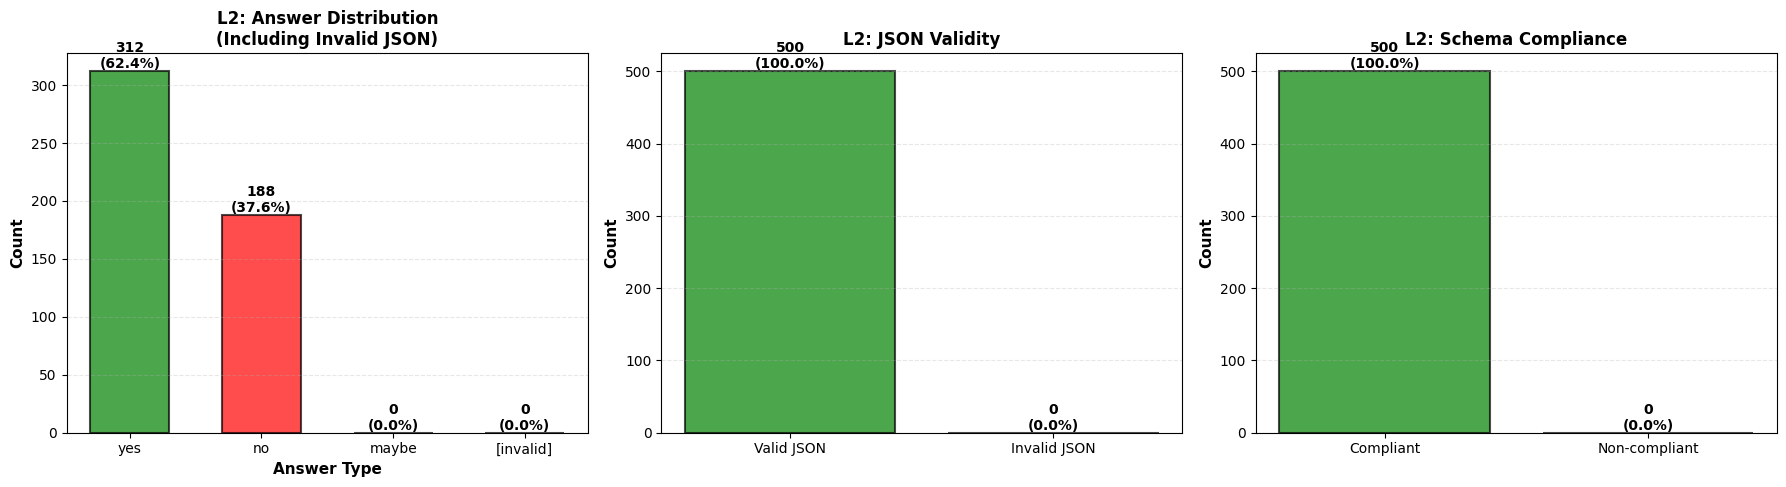

In [46]:
# Create visualizations for L2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Answer Distribution (including invalid JSON)
ax1 = axes[0]
x_pos = np.arange(len(l2_categories))
bars1 = ax1.bar(x_pos, l2_counts, color=['green', 'red', 'orange', 'gray'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, l2_counts):
    height = bar.get_height()
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('L2: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(l2_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# 2. JSON Validity
ax2 = axes[1]
valid_count = l2_valid_json_count
invalid_count = l2_total - l2_valid_json_count
bars2 = ax2.bar(['Valid JSON', 'Invalid JSON'], [valid_count, invalid_count], 
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars2, [valid_count, invalid_count]):
    height = bar.get_height()
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L2: JSON Validity', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# 3. Schema Compliance
ax3 = axes[2]
compliant_count = l2_compliant
non_compliant_count = l2_total - l2_compliant
bars3 = ax3.bar(['Compliant', 'Non-compliant'], [compliant_count, non_compliant_count],
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars3, [compliant_count, non_compliant_count]):
    height = bar.get_height()
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('L2: Schema Compliance', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_559570/896347516.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(conf_by_type_data, labels=conf_by_type_labels, patch_artist=True)


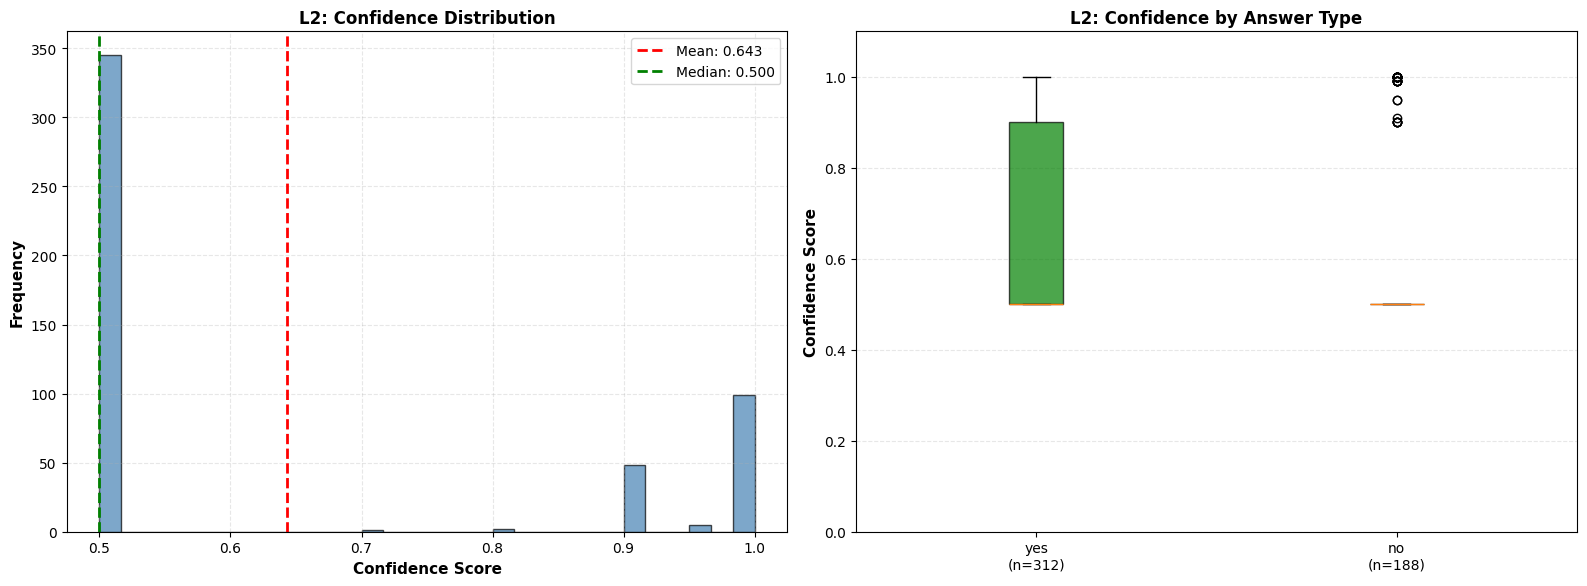

In [ ]:
# Confidence Distribution Histogram and Confidence by Answer Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confidence Distribution Histogram
ax1 = axes[0]
if l2_valid_confidences:
    ax1.hist(l2_valid_confidences, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(np.mean(l2_valid_confidences), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {np.mean(l2_valid_confidences):.3f}')
    ax1.axvline(np.median(l2_valid_confidences), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {np.median(l2_valid_confidences):.3f}')
    ax1.set_xlabel('Confidence Score', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax1.set_title('L2: Confidence Distribution', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3, linestyle='--')
else:
    ax1.text(0.5, 0.5, 'No valid\nconfidence scores', 
            ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('L2: Confidence Distribution', fontsize=12, fontweight='bold')
ax1.tick_params(labelsize=10)

# 2. Confidence by Answer Type
ax2 = axes[1]
conf_by_type_data = []
conf_by_type_labels = []
for answer_type in ['yes', 'no', 'maybe']:
    conf_by_type = [l2_confidences[i] for i, ans in enumerate(l2_answers) 
                   if ans == answer_type and l2_confidences[i] is not None]
    if conf_by_type:
        conf_by_type_data.append(conf_by_type)
        conf_by_type_labels.append(f'{answer_type}\n(n={len(conf_by_type)})')

if conf_by_type_data:
    bp = ax2.boxplot(conf_by_type_data, labels=conf_by_type_labels, patch_artist=True)
    colors_box = ['green', 'red', 'orange']
    for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_ylabel('Confidence Score', fontsize=11, fontweight='bold')
    ax2.set_title('L2: Confidence by Answer Type', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_ylim([0, 1.1])
else:
    ax2.text(0.5, 0.5, 'No valid\nconfidence scores', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('L2: Confidence by Answer Type', fontsize=12, fontweight='bold')
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


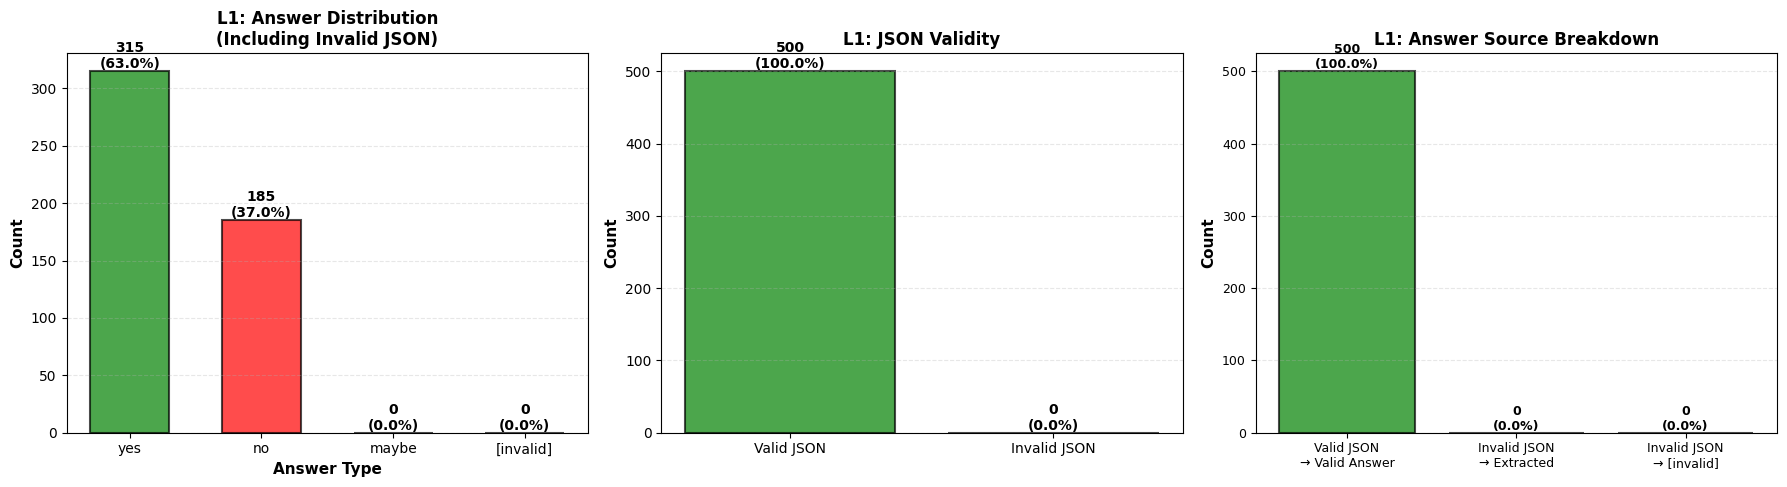

In [48]:
# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Answer Distribution (including invalid JSON)
ax1 = axes[0]
x_pos = np.arange(len(l1_categories))
bars1 = ax1.bar(x_pos, l1_counts, color=['green', 'red', 'orange', 'gray'], alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, l1_counts):
    height = bar.get_height()
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('L1: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(l1_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# 2. JSON Validity
ax2 = axes[1]
valid_count = l1_valid_json_count
invalid_count = l1_total - l1_valid_json_count
bars2 = ax2.bar(['Valid JSON', 'Invalid JSON'], [valid_count, invalid_count], 
                color=['green', 'red'], alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars2, [valid_count, invalid_count]):
    height = bar.get_height()
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L1: JSON Validity', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# 3. Answer Source Breakdown
ax3 = axes[2]
# Categorize answers by source
from_valid_json = l1_compliant
from_invalid_json = sum([1 for i in range(l1_total) if not l1_valid_json[i] and l1_answers[i] != '[invalid]'])
invalid_answers = l1_counts[3]

categories_source = ['Valid JSON\n→ Valid Answer', 'Invalid JSON\n→ Extracted', 'Invalid JSON\n→ [invalid]']
counts_source = [from_valid_json, from_invalid_json, invalid_answers]
colors_source = ['green', 'orange', 'red']

bars3 = ax3.bar(categories_source, counts_source, color=colors_source, alpha=0.7, edgecolor='black', linewidth=1.5)
for bar, count in zip(bars3, counts_source):
    height = bar.get_height()
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('L1: Answer Source Breakdown', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.tick_params(labelsize=9)

plt.tight_layout()
plt.show()


## Baseline vs L1 vs L2 Comprehensive Comparison


In [ ]:
# Comprehensive Three-Way Comparison: Baseline vs L1 vs L2
print("="*80)
print("BASELINE vs L1 vs L2 COMPREHENSIVE COMPARISON")
print("="*80)

print(f"\n📊 Task Performance (Exact Match):")
print(f"   Baseline: {baseline_exact_match:.4f} ± {baseline_exact_match_stderr:.4f} ({baseline_exact_match*100:.2f}%)")
print(f"   L1:       {l1_exact_match:.4f} ± {l1_exact_match_stderr:.4f} ({l1_exact_match*100:.2f}%)")
print(f"   L2:       {l2_exact_match:.4f} ± {l2_exact_match_stderr:.4f} ({l2_exact_match*100:.2f}%)")
diff_l1 = (l1_exact_match - baseline_exact_match) * 100
diff_l2 = (l2_exact_match - baseline_exact_match) * 100
diff_l2_l1 = (l2_exact_match - l1_exact_match) * 100
print(f"\n   L1 vs Baseline: {diff_l1:+.2f} percentage points")
print(f"   L2 vs Baseline: {diff_l2:+.2f} percentage points")
print(f"   L2 vs L1: {diff_l2_l1:+.2f} percentage points")

print(f"\n📈 Answer Distribution:")
print(f"   {'Category':<15} {'Baseline':<20} {'L1':<20} {'L2':<20}")
print(f"   {'-'*15} {'-'*20} {'-'*20} {'-'*20}")
for i, cat in enumerate(baseline_categories):
    baseline_count = baseline_counts[i]
    baseline_pct = baseline_count / baseline_total * 100 if baseline_total > 0 else 0
    l1_count = l1_counts[i] if i < len(l1_counts) else 0
    l1_pct = l1_count / l1_total * 100 if l1_total > 0 else 0
    l2_count = l2_counts[i] if i < len(l2_counts) else 0
    l2_pct = l2_count / l2_total * 100 if l2_total > 0 else 0
    print(f"   {cat:<15} {baseline_count:4d} ({baseline_pct:5.2f}%)    {l1_count:4d} ({l1_pct:5.2f}%)    {l2_count:4d} ({l2_pct:5.2f}%)")

print(f"\n   {'Total':<15} {baseline_total:<20} {l1_total:<20} {l2_total:<20}")
print(f"   {'Valid answers':<15} {sum(baseline_counts[:3]):<20} {sum(l1_counts[:3]):<20} {sum(l2_counts[:3]):<20}")
print(f"   {'Invalid answers':<15} {baseline_counts[3]:<20} {l1_counts[3]:<20} {l2_counts[3]:<20}")

print(f"\n🔍 Schema Compliance:")
print(f"   {'Metric':<30} {'L1':<20} {'L2':<20}")
print(f"   {'-'*30} {'-'*20} {'-'*20}")
print(f"   {'Valid JSON':<30} {l1_valid_json_count}/{l1_total} ({l1_valid_json_count/l1_total*100:.2f}%)    {l2_valid_json_count}/{l2_total} ({l2_valid_json_count/l2_total*100:.2f}%)")
print(f"   {'Full Schema Compliance':<30} {l1_compliant}/{l1_total} ({l1_compliant/l1_total*100:.2f}%)    {l2_compliant}/{l2_total} ({l2_compliant/l2_total*100:.2f}%)")
if l2_valid_confidences:
    print(f"   {'L2 Valid Confidence Scores':<30} {'N/A':<20} {len(l2_valid_confidences)}/{l2_total} ({len(l2_valid_confidences)/l2_total*100:.2f}%)")
    print(f"   {'L2 Mean Confidence':<30} {'N/A':<20} {np.mean(l2_valid_confidences):.4f}")

print("="*80)


BASELINE vs L1 vs L2 COMPREHENSIVE COMPARISON

📊 Task Performance (Exact Match):
   Baseline: 0.7620 ± 0.0191 (76.20%)
   L1:       0.7720 ± 0.0188 (77.20%)
   L2:       0.7740 ± 0.0187 (77.40%)

   L1 vs Baseline: +1.00 percentage points
   L2 vs Baseline: +1.20 percentage points
   L2 vs L1: +0.20 percentage points

📈 Answer Distribution:
   Category        Baseline             L1                   L2                  
   --------------- -------------------- -------------------- --------------------
   yes              344 (68.80%)     315 (63.00%)     312 (62.40%)
   no               151 (30.20%)     185 (37.00%)     188 (37.60%)
   maybe              2 ( 0.40%)       0 ( 0.00%)       0 ( 0.00%)
   [invalid]          3 ( 0.60%)       0 ( 0.00%)       0 ( 0.00%)

   Total           500                  500                  500                 
   Valid answers   497                  500                  500                 
   Invalid answers 3                    0                   

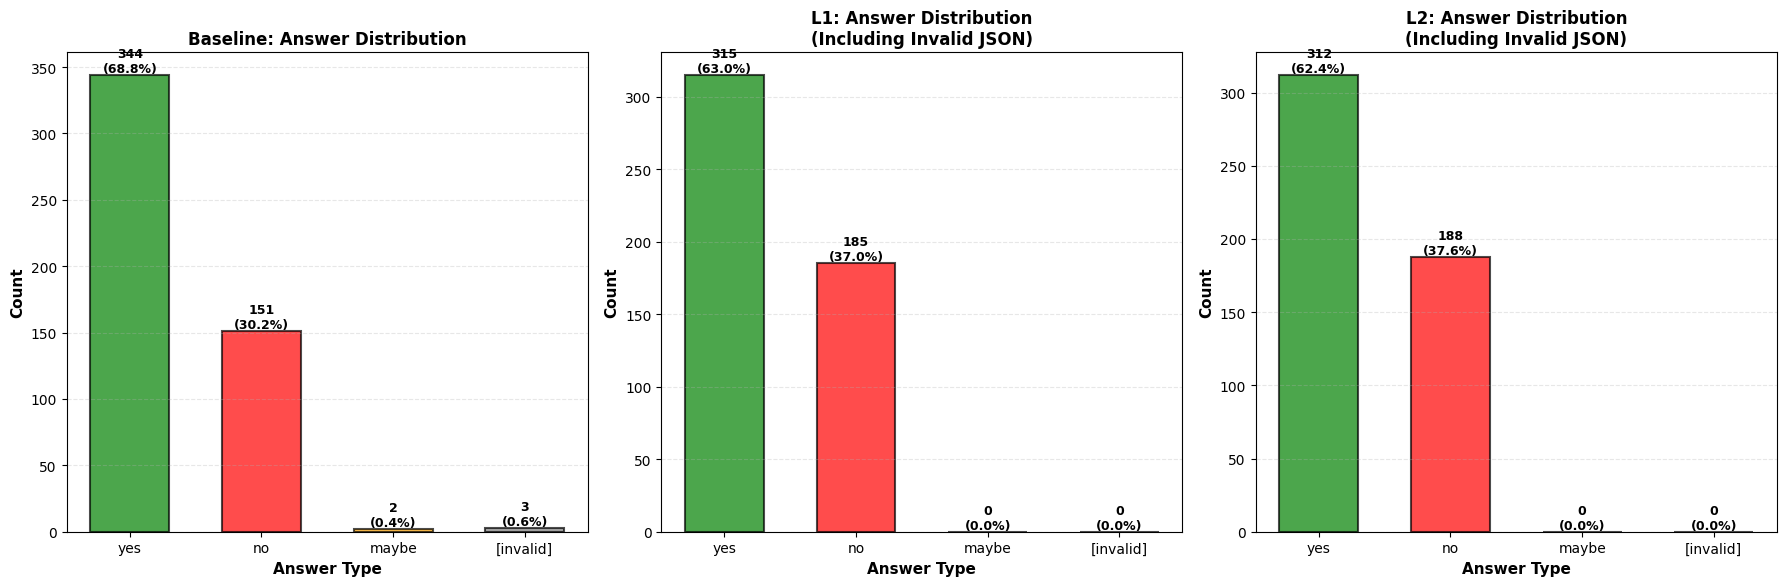

In [50]:
# Visualize Three-Way Comparison: Baseline vs L1 vs L2
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Baseline distribution
ax1 = axes[0]
x_pos = np.arange(len(baseline_categories))
bars1 = ax1.bar(x_pos, baseline_counts, color=['green', 'red', 'orange', 'gray'], 
                alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars1, baseline_counts):
    height = bar.get_height()
    percentage = count / baseline_total * 100 if baseline_total > 0 else 0
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11, fontweight='bold')
ax1.set_title('Baseline: Answer Distribution', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(baseline_categories, fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(labelsize=10)

# L1 distribution
ax2 = axes[1]
x_pos2 = np.arange(len(l1_categories))
bars2 = ax2.bar(x_pos2, l1_counts, color=['green', 'red', 'orange', 'gray'], 
                alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars2, l1_counts):
    height = bar.get_height()
    percentage = count / l1_total * 100 if l1_total > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('L1: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(l1_categories, fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(labelsize=10)

# L2 distribution
ax3 = axes[2]
x_pos3 = np.arange(len(l2_categories))
bars3 = ax3.bar(x_pos3, l2_counts, color=['green', 'red', 'orange', 'gray'], 
                alpha=0.7, edgecolor='black', linewidth=1.5, width=0.6)
for bar, count in zip(bars3, l2_counts):
    height = bar.get_height()
    percentage = count / l2_total * 100 if l2_total > 0 else 0
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_xlabel('Answer Type', fontsize=11, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
ax3.set_title('L2: Answer Distribution\n(Including Invalid JSON)', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos3)
ax3.set_xticklabels(l2_categories, fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.tick_params(labelsize=10)

plt.tight_layout()
plt.show()
